# Exploração do limite municipal do IBGE

Este notebook inspeciona o GeoJSON Bronze original de Sorriso-MT, valida sua estrutura e apresenta a geometria que define a área de estudo das demais fontes.

## Carregamento da fonte

O arquivo é lido diretamente da camada Bronze, sem alterar coordenadas ou atributos. O caminho relativo funciona tanto na raiz do projeto quanto no diretório `notebooks/`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import shape

PROJECT_ROOT = Path(".") if Path("data").exists() else Path("..")
IBGE_PATH = (
    PROJECT_ROOT / "data/bronze/ibge/municipality/municipality_code=5107925/municipality.geojson"
)
MANIFEST_PATH = IBGE_PATH.with_name("municipality.manifest.json")

if not IBGE_PATH.exists():
    raise FileNotFoundError(
        f"Limite municipal não encontrado em {IBGE_PATH}. Execute a ingestão IBGE primeiro."
    )

document = json.loads(IBGE_PATH.read_text(encoding="utf-8"))
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
feature = document["features"][0] if document["type"] == "FeatureCollection" else document
geometry = shape(feature["geometry"])

print(f"Tipo do documento: {document['type']}")
print(f"Tipo da geometria: {geometry.geom_type}")
print(f"Geometria válida: {geometry.is_valid}")
pd.Series(feature.get("properties", {}), name="valor").to_frame()

Tipo do documento: FeatureCollection
Tipo da geometria: Polygon
Geometria válida: True


,valor
codarea,5107925


## Extensão espacial e ponto representativo

Os limites são apresentados em longitude e latitude, pois o GeoJSON usa coordenadas geográficas. O ponto representativo fica garantidamente dentro do município e é o ponto usado como referência para fontes pontuais, como a NASA POWER.

In [2]:
min_lon, min_lat, max_lon, max_lat = geometry.bounds
representative_point = geometry.representative_point()
summary = pd.Series(
    {
        "minimum_longitude": min_lon,
        "minimum_latitude": min_lat,
        "maximum_longitude": max_lon,
        "maximum_latitude": max_lat,
        "representative_longitude": representative_point.x,
        "representative_latitude": representative_point.y,
        "representative_point_inside": geometry.contains(representative_point),
    },
    name="valor",
).to_frame()
summary

,valor
minimum_longitude,-56.1167
minimum_latitude,-13.6634
maximum_longitude,-55.0851
maximum_latitude,-11.7253
representative_longitude,-55.775624
representative_latitude,-12.69195
representative_point_inside,True


## Visualização da área de estudo

O contorno representa a geometria oficial preservada. O marcador indica o ponto interno derivado em memória; ele não constitui uma nova camada persistida.

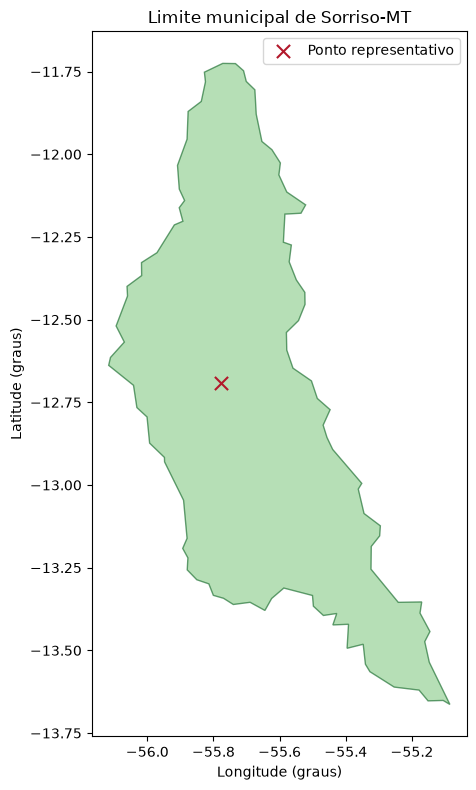

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
parts = list(geometry.geoms) if geometry.geom_type == "MultiPolygon" else [geometry]
for polygon in parts:
    x, y = polygon.exterior.xy
    ax.fill(x, y, color="#8fcf8f", edgecolor="#176b2c", alpha=0.65)
ax.scatter(
    representative_point.x,
    representative_point.y,
    color="#b2182b",
    marker="x",
    s=90,
    label="Ponto representativo",
)
ax.set(
    title="Limite municipal de Sorriso-MT",
    xlabel="Longitude (graus)",
    ylabel="Latitude (graus)",
)
ax.set_aspect("equal")
ax.legend()
fig.tight_layout()
plt.show()

## Rastreabilidade

O manifesto permite auditar origem, momento da coleta, tamanho e checksum do arquivo. Esses metadados demonstram qual resposta oficial foi usada nas análises seguintes.

In [4]:
pd.Series(manifest, name="valor").to_frame()

,valor
config_sha256,73b625776bbdaa65b2d07d8b6d4eea8304a4dc4b08edcc...
content_type,application/vnd.geo+json
dataset,municipal_boundary
downloaded_at_utc,2026-08-06T02:00:34.275810+00:00
final_url,https://servicodados.ibge.gov.br/api/v3/malhas...
http_status,200
municipality_code,5107925
municipality_name,Sorriso
parameters,"{'formato': 'application/vnd.geo+json', 'quali..."
project_version,0.1.0
